Starting Lab 1 Comparison...

--- Training Keras ---
--- Training PyTorch ---
--- Training TF Low-Level ---


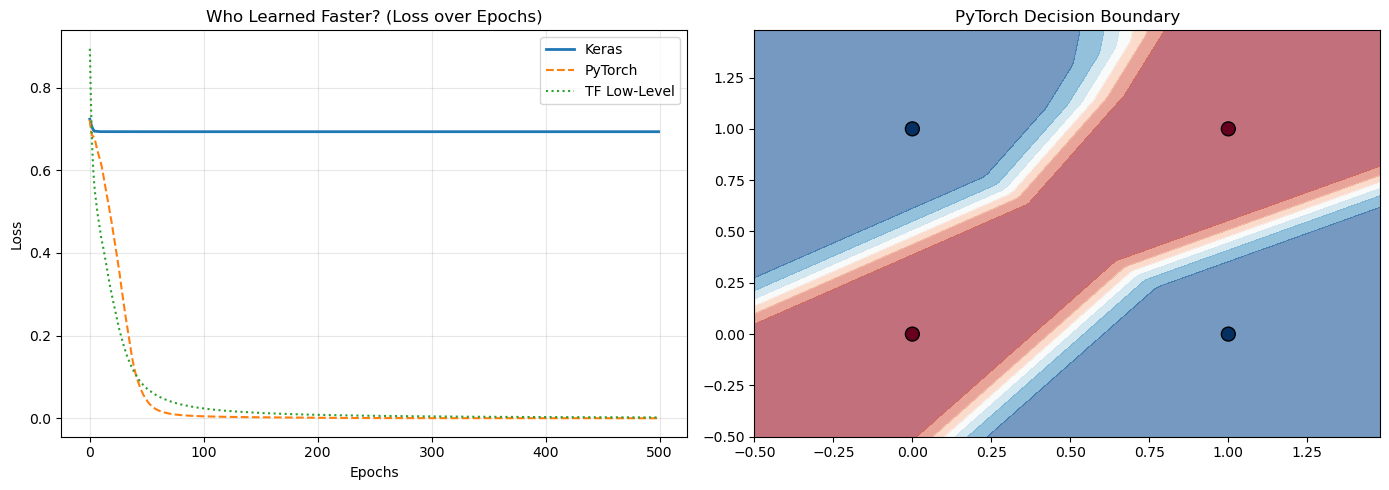


Final XOR Predictions (PyTorch Model):
Inputs:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Predicted Probability:
[[2.1313126e-04]
 [9.9986994e-01]
 [9.9989450e-01]
 [7.0191323e-05]]
Final Logic Result:
[[0.]
 [1.]
 [1.]
 [0.]]


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# XOR Inputs and Outputs
X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# Global Settings
EPOCHS = 500         
LEARNING_RATE = 0.05  
results = {}


# 1. KERAS IMPLEMENTATION
print("Training Keras")
tf.random.set_seed(42)

model_keras = Sequential([
    Dense(8, input_dim=2, activation='relu'), 
    Dense(1, activation='sigmoid')            
])

model_keras.compile(loss='binary_crossentropy', 
                    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE))

history = model_keras.fit(X, y, epochs=EPOCHS, verbose=0)
results['Keras'] = history.history['loss']


# 2. PYTORCH IMPLEMENTATION
print("Training PyTorch")
torch.manual_seed(42)
X_torch = torch.from_numpy(X)
y_torch = torch.from_numpy(y)

class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.layer1 = nn.Linear(2, 8)
        self.layer2 = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.sigmoid(self.layer2(x))
        return x

model_pt = SimpleNet()
optimizer = optim.Adam(model_pt.parameters(), lr=LEARNING_RATE)
criterion = nn.BCELoss()
losses_pt = []

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    output = model_pt(X_torch)
    loss = criterion(output, y_torch)
    loss.backward()
    optimizer.step()
    losses_pt.append(loss.item())

results['PyTorch'] = losses_pt


# 3. TENSORFLOW LOW-LEVEL IMPLEMENTATION

print("" \
"Training TF Low-Level")
tf.random.set_seed(42)

W1 = tf.Variable(tf.random.normal([2, 8], seed=42))
b1 = tf.Variable(tf.zeros([8]))
W2 = tf.Variable(tf.random.normal([8, 1], seed=42))
b2 = tf.Variable(tf.zeros([1]))

optimizer_tf = tf.optimizers.Adam(learning_rate=LEARNING_RATE)
losses_tf = []

for epoch in range(EPOCHS):
    with tf.GradientTape() as tape:
        z1 = tf.matmul(X, W1) + b1
        a1 = tf.nn.relu(z1)
        z2 = tf.matmul(a1, W2) + b2
        pred = tf.nn.sigmoid(z2)
        loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y, pred))
    
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer_tf.apply_gradients(zip(gradients, [W1, b1, W2, b2]))
    losses_tf.append(loss.numpy())

results['TF Low-Level'] = losses_tf


# 4. Loss and Decision Boundary


def plot_boundary(X, y, model_type, model_obj=None, ax=None):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    if model_type == 'Keras':
        preds = model_obj.predict(grid, verbose=0)
    elif model_type == 'PyTorch':
        with torch.no_grad():
            preds = model_obj(torch.from_numpy(grid)).numpy()
    else:
        z1 = tf.matmul(grid, W1) + b1
        a1 = tf.nn.relu(z1)
        preds = tf.nn.sigmoid(tf.matmul(a1, W2) + b2).numpy()

    preds = preds.reshape(xx.shape)
    ax.contourf(xx, yy, preds, cmap='RdBu', alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=100, edgecolors='k', cmap='RdBu')
    ax.set_title(f'{model_type} Decision Boundary')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Convergence
axes[0].plot(results['Keras'], label='Keras', linewidth=2)
axes[0].plot(results['PyTorch'], label='PyTorch', linestyle='--')
axes[0].plot(results['TF Low-Level'], label='TF Low-Level', linestyle=':')
axes[0].set_title('Who Learned Faster? (Loss over Epochs)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Boundary (Using PyTorch as Example)
plot_boundary(X, y, 'PyTorch', model_pt, axes[1])

plt.tight_layout()
plt.show()

# Final Predictions
print("\nFinal XOR Predictions (PyTorch Model):")
with torch.no_grad():
    pt_preds = model_pt(X_torch).numpy()
    print(f"Inputs:\n{X}")
    print(f"Predicted Probability:\n{pt_preds}")
    print(f"Final Logic Result:\n{np.round(pt_preds)}")